<a href="https://colab.research.google.com/github/Korobokkk/Deep_Learning/blob/main/Image_Captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Гружу данные

In [5]:
import requests
from urllib.parse import urlencode

endpoint_api_func_download = 'https://cloud-api.yandex.net/v1/disk/public/resources/download'
public_link = 'https://disk.yandex.ru/d/W9EODR61Dj1Oxg'

#full_link = endpoint_api_func_download + urlencode(dict(public_key=public_link)) # как я понял для перевода : -> %3A & / -> %2F
response = requests.get(endpoint_api_func_download, params={'public_key': public_link})
download_url = response.json()['href']

download_response = requests.get(download_url)
with open ('dataset_train.tar.gz', 'wb') as f:
  f.write(download_response.content)

# 1. Подготовка данных

Размер архива

In [6]:
!ls -sh dataset_train.tar.gz

2.2G dataset_train.tar.gz


Тип файла и его размер до сжатия

In [7]:
!file dataset_train.tar.gz

dataset_train.tar.gz: gzip compressed data, from Unix, original size modulo 2^32 2370375680


Чек на целостность архива

In [8]:
!gzip -t dataset_train.tar.gz

Распаковка

In [9]:
!mkdir -p ImageSwaga
!tar xfz dataset_train.tar.gz -C ImageSwaga

In [10]:
import torch
import cv2
import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
!ls -sh ImageSwaga/data
data_folder= "./ImageSwaga/data"

dfs = dict()
for split in ['train', 'val']:
  dfs[split] = pd.read_csv(os.path.join(data_folder, f'captions_{split}.tsv'), sep='\t')

dfs['train'].head()

total 2.0M
1.7M captions_train.tsv  144K captions_val.tsv	136K train   12K val


,img_id,caption #0,caption #1,caption #2,caption #3,caption #4
0,0000.png,A child in a pink dress is climbing up a set o...,A girl going into a wooden building .,A little girl climbing into a wooden playhouse .,A little girl climbing the stairs to her playh...,A little girl in a pink dress going into a woo...
1,0001.png,A black dog and a spotted dog are fighting,A black dog and a tri-colored dog playing with...,A black dog and a white dog with brown spots a...,Two dogs of different breeds looking at each o...,Two dogs on pavement moving toward each other .
2,0002.png,A little girl covered in paint sits in front o...,A little girl is sitting in front of a large p...,A small girl in the grass plays with fingerpai...,There is a girl with pigtails sitting in front...,Young girl with pigtails painting outside in t...
3,0003.png,A man lays on a bench while his dog sits by him .,A man lays on the bench to which a white dog i...,a man sleeping on a bench outside with a white...,A shirtless man lies on a park bench with his ...,man laying on bench holding leash of dog sitti...
4,0004.png,A man in an orange hat starring at something .,A man wears an orange hat and glasses .,A man with gauges and glasses is wearing a Bli...,A man with glasses is wearing a beer can croch...,The man with pierced ears is wearing glasses a...


In [12]:
dfs['train'].shape
dfs['val'].shape

(500, 6)

<class 'numpy.ndarray'>
(375, 500, 3)


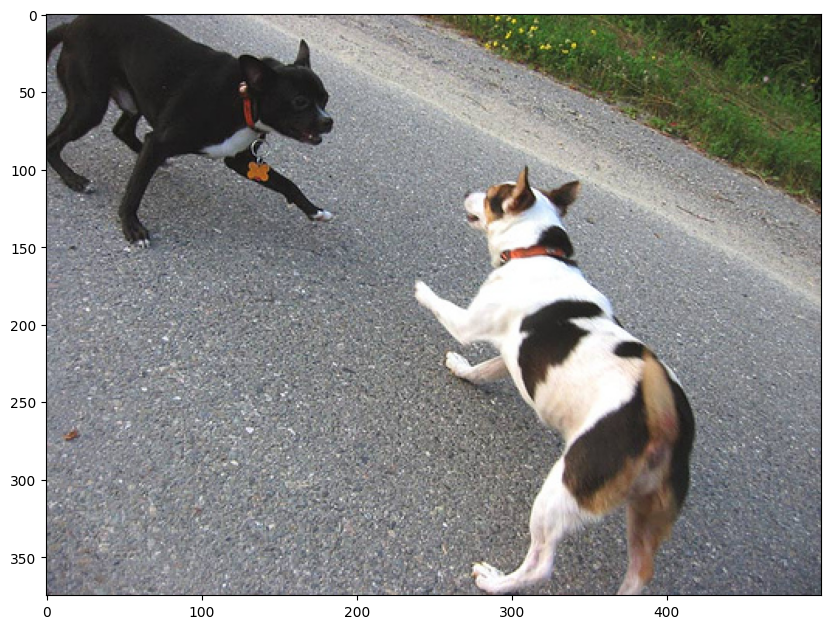

In [13]:
fig, ax = plt.subplots(figsize=(10,8))
image = cv2.imread(os.path.join(data_folder, 'train', '0001.png'))
print(type(image))
print(image.shape)
plt.imshow(image)
plt.show()

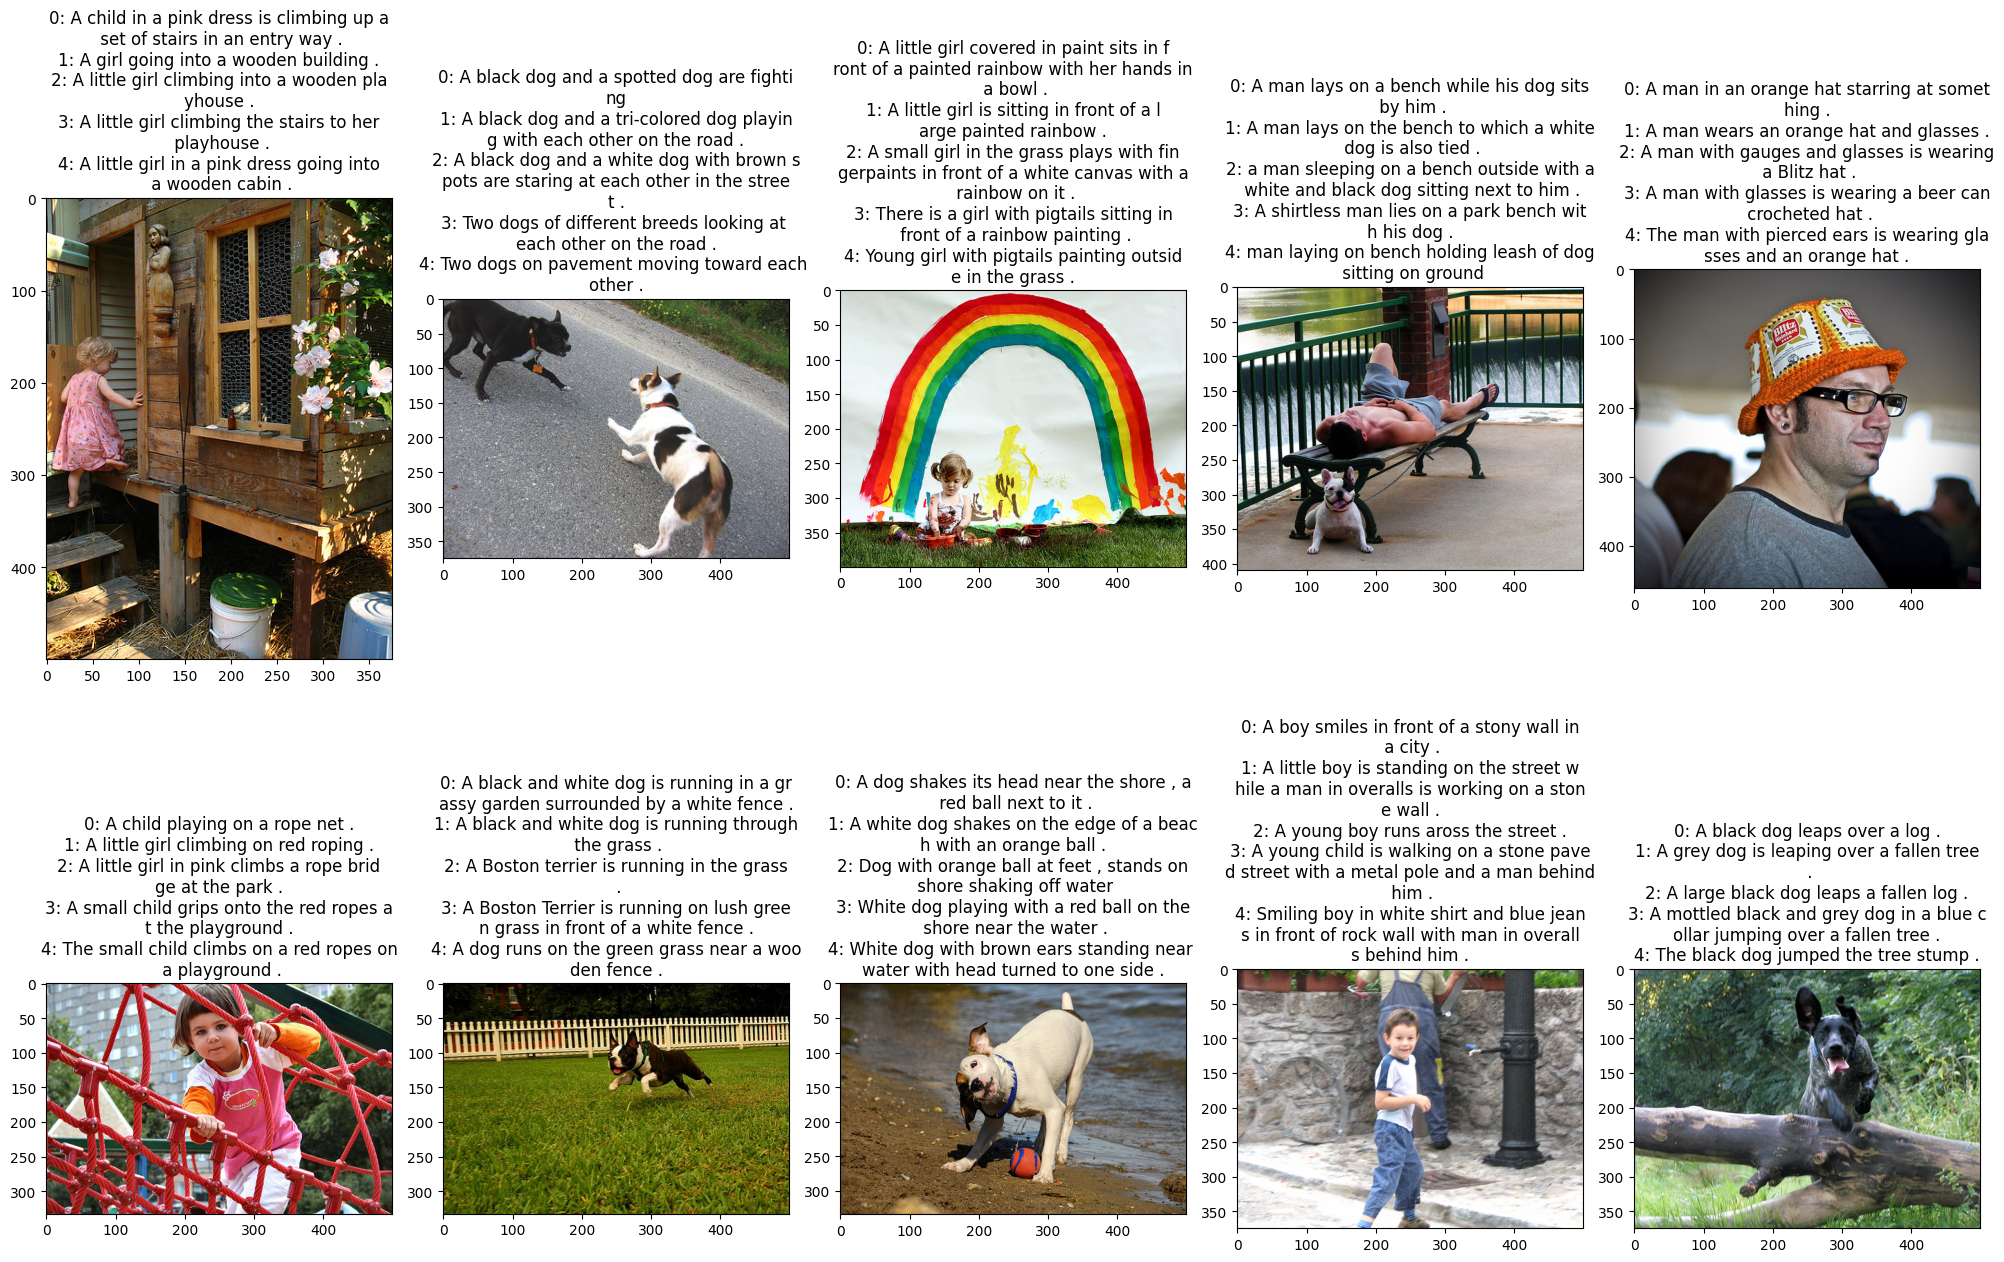

In [14]:
index = list(range(10))
split = 'train'
h, w = 2, 5
title_width = 43

fig, ax = plt.subplots(h, w, figsize=(20, 15))
for i, i_index in enumerate(index):
  row = dfs[split].iloc[i_index]
  img_id = row['img_id']
  captions = [row[f'caption #{i}'] for i in range(5)]
  caption_adjasted = map(lambda caps: '\n'.join([(str(caps[0]) + ': ' + caps[1])[k:k+title_width] for k in range(0, 3 + len(caps[1]), title_width)]) , enumerate(captions))
  caption = '\n'.join(caption_adjasted)

  plt.subplot(h, w, i + 1)
  plt.title(caption)
  plt.imshow(cv2.imread(os.path.join(data_folder, split, img_id)))

fig.tight_layout()
plt.show()

## 1.2 Предобработка изображений

In [15]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tr

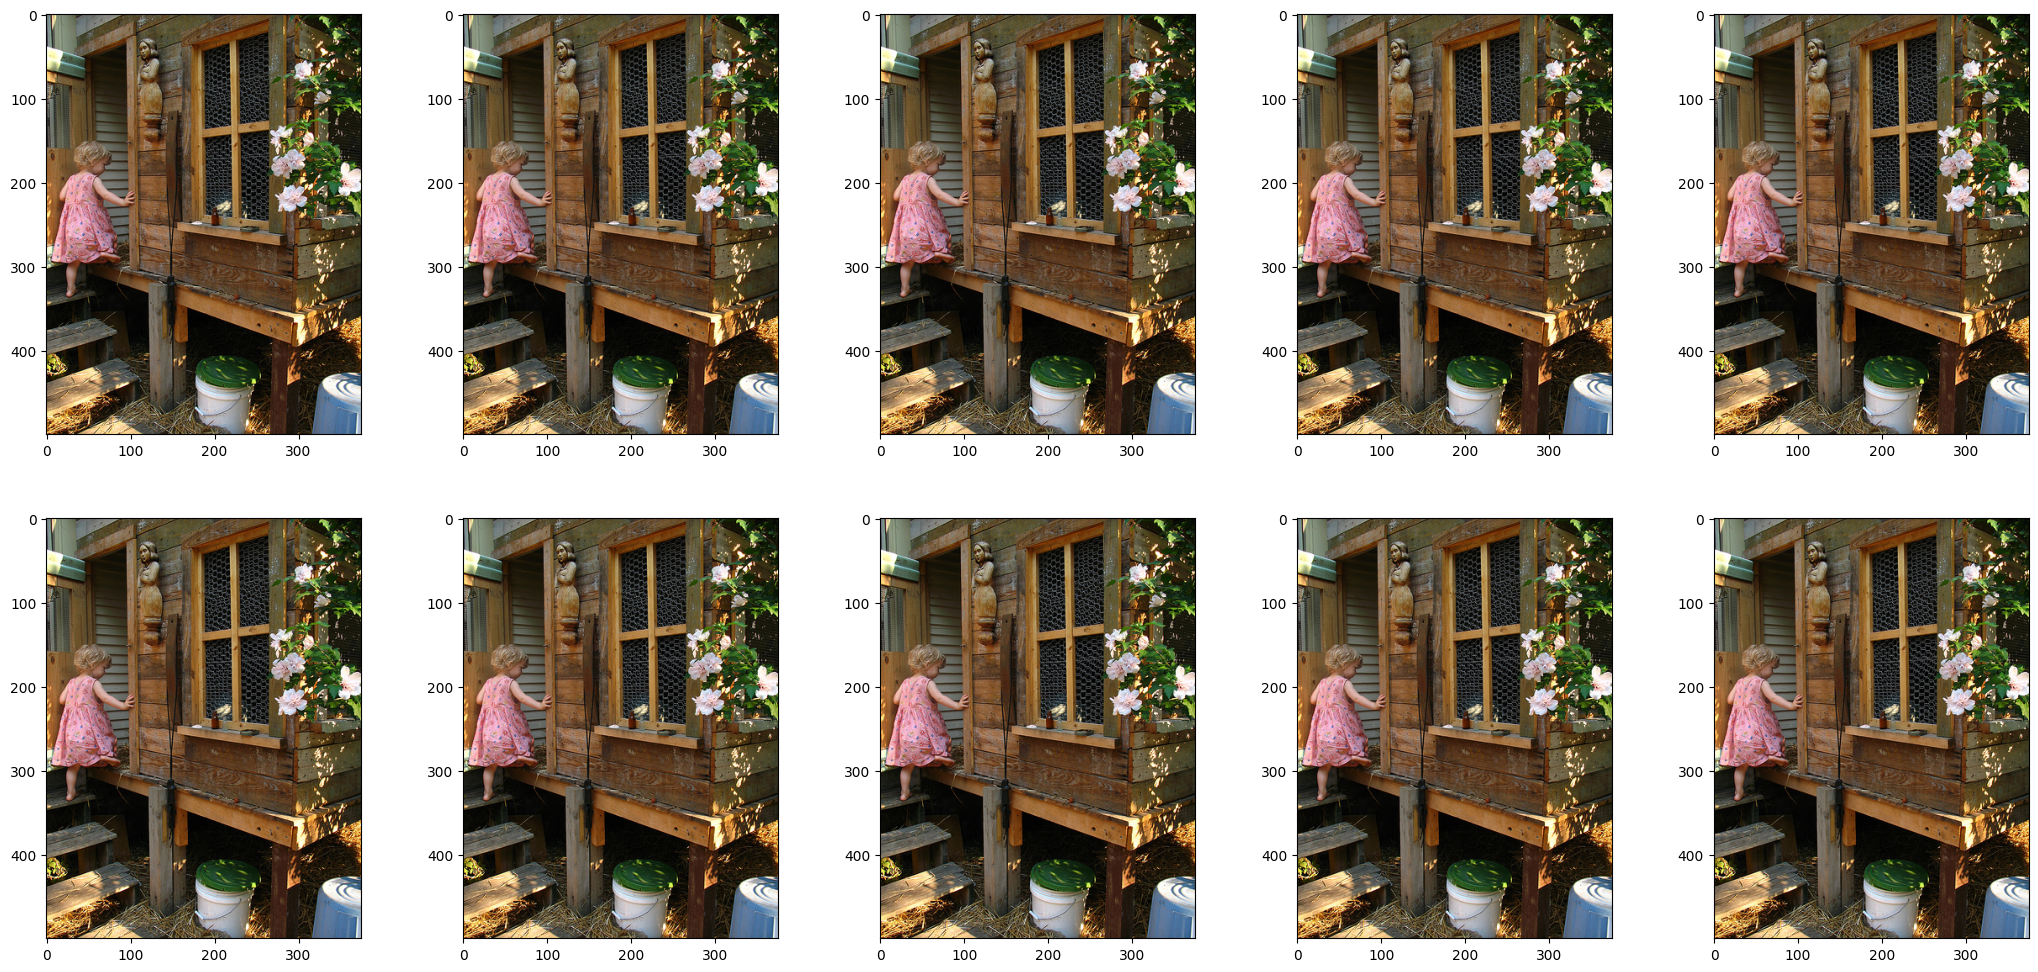

In [16]:
channel_mean = np.array([1/10, 1/10, 1/10])
channel_std = np.array([1/10, 1/10, 1/10])

image_prepare = tr.Compose([
    tr.ToPILImage(),
    tr.ToTensor(),
    tr.Normalize(mean = channel_mean, std = channel_std)

])

image_prepare_val = tr.Compose([
    tr.ToPILImage(),
    #...,
    tr.ToTensor(),
    #...,
    tr.Normalize(mean=channel_mean, std=channel_std)
])


from sklearn.preprocessing import minmax_scale

image = cv2.imread(os.path.join(data_folder, "train", "0000.png"))

def de_normalize(img):
    return minmax_scale(
        (img.reshape(3, -1) + channel_mean[:, None]) * channel_std[:, None],
        feature_range=(0., 1.),
        axis=1,
    ).reshape(*img.shape)


fig, ax = plt.subplots(2, 5, figsize=(26, 12))
for i in range(10):
    plt.subplot(2, 5, i+1)
    transformed_image = image_prepare(image).numpy().transpose(1, 2, 0)
    to_show_image = de_normalize(transformed_image)
    plt.imshow(to_show_image)
plt.show()

# 1.3 Предобработка изображения

In [17]:
import re

def tokenize(text):
  text = text.lower()
  sym_flags = f"[{re.escape(',.!?;:)(@#$^&*-=+%№"_')}]"
  text = re.sub(sym_flags, ' ', text)
  text = text.strip()
  text = text.split()

  text.insert(0, '<BOS>')
  text.append('<EOS>')
  return text

res = tokenize("My name is Any0019, I wish you good luck in this lab! Bye-bye :)")
print(res)

['<BOS>', 'my', 'name', 'is', 'any0019', 'i', 'wish', 'you', 'good', 'luck', 'in', 'this', 'lab', 'bye', 'bye', '<EOS>']


  0%|          | 0/6000 [00:00<?, ?it/s]

Counter({'a': 46784, 'in': 14094, 'the': 13509, 'on': 8007, 'is': 6907, 'and': 6678, 'dog': 6160, 'with': 5763, 'man': 5383, 'of': 4974, 'two': 4250, 'white': 2932, 'black': 2865, 'boy': 2634, 'are': 2619, 'woman': 2543, 'girl': 2414, 'to': 2306, 'wearing': 2271, 'at': 2102, 'people': 2093, 'water': 2031, 'brown': 2008, 'red': 1987, 'young': 1976, 'an': 1807, 'his': 1711, 'blue': 1676, 'dogs': 1620, 'running': 1589, 'through': 1533, 'shirt': 1490, 'playing': 1486, 'while': 1443, 'down': 1381, 'ball': 1339, 'standing': 1302, 'little': 1266, 'grass': 1222, 'snow': 1214, 'child': 1120, 'person': 1119, 'jumping': 1103, 'over': 1063, 'three': 1052, 'sitting': 1018, 'field': 997, 'front': 996, 'holding': 972, 'small': 940, 'up': 933, 'green': 931, 'yellow': 930, 'group': 909, 'by': 904, 'large': 895, 'one': 876, 'walking': 870, 'her': 861, 'men': 856, 'children': 837, 'air': 773, 'into': 757, 'near': 752, 'mouth': 744, 'beach': 743, 'jumps': 726, 'runs': 724, 'another': 713, 'for': 706, 'str

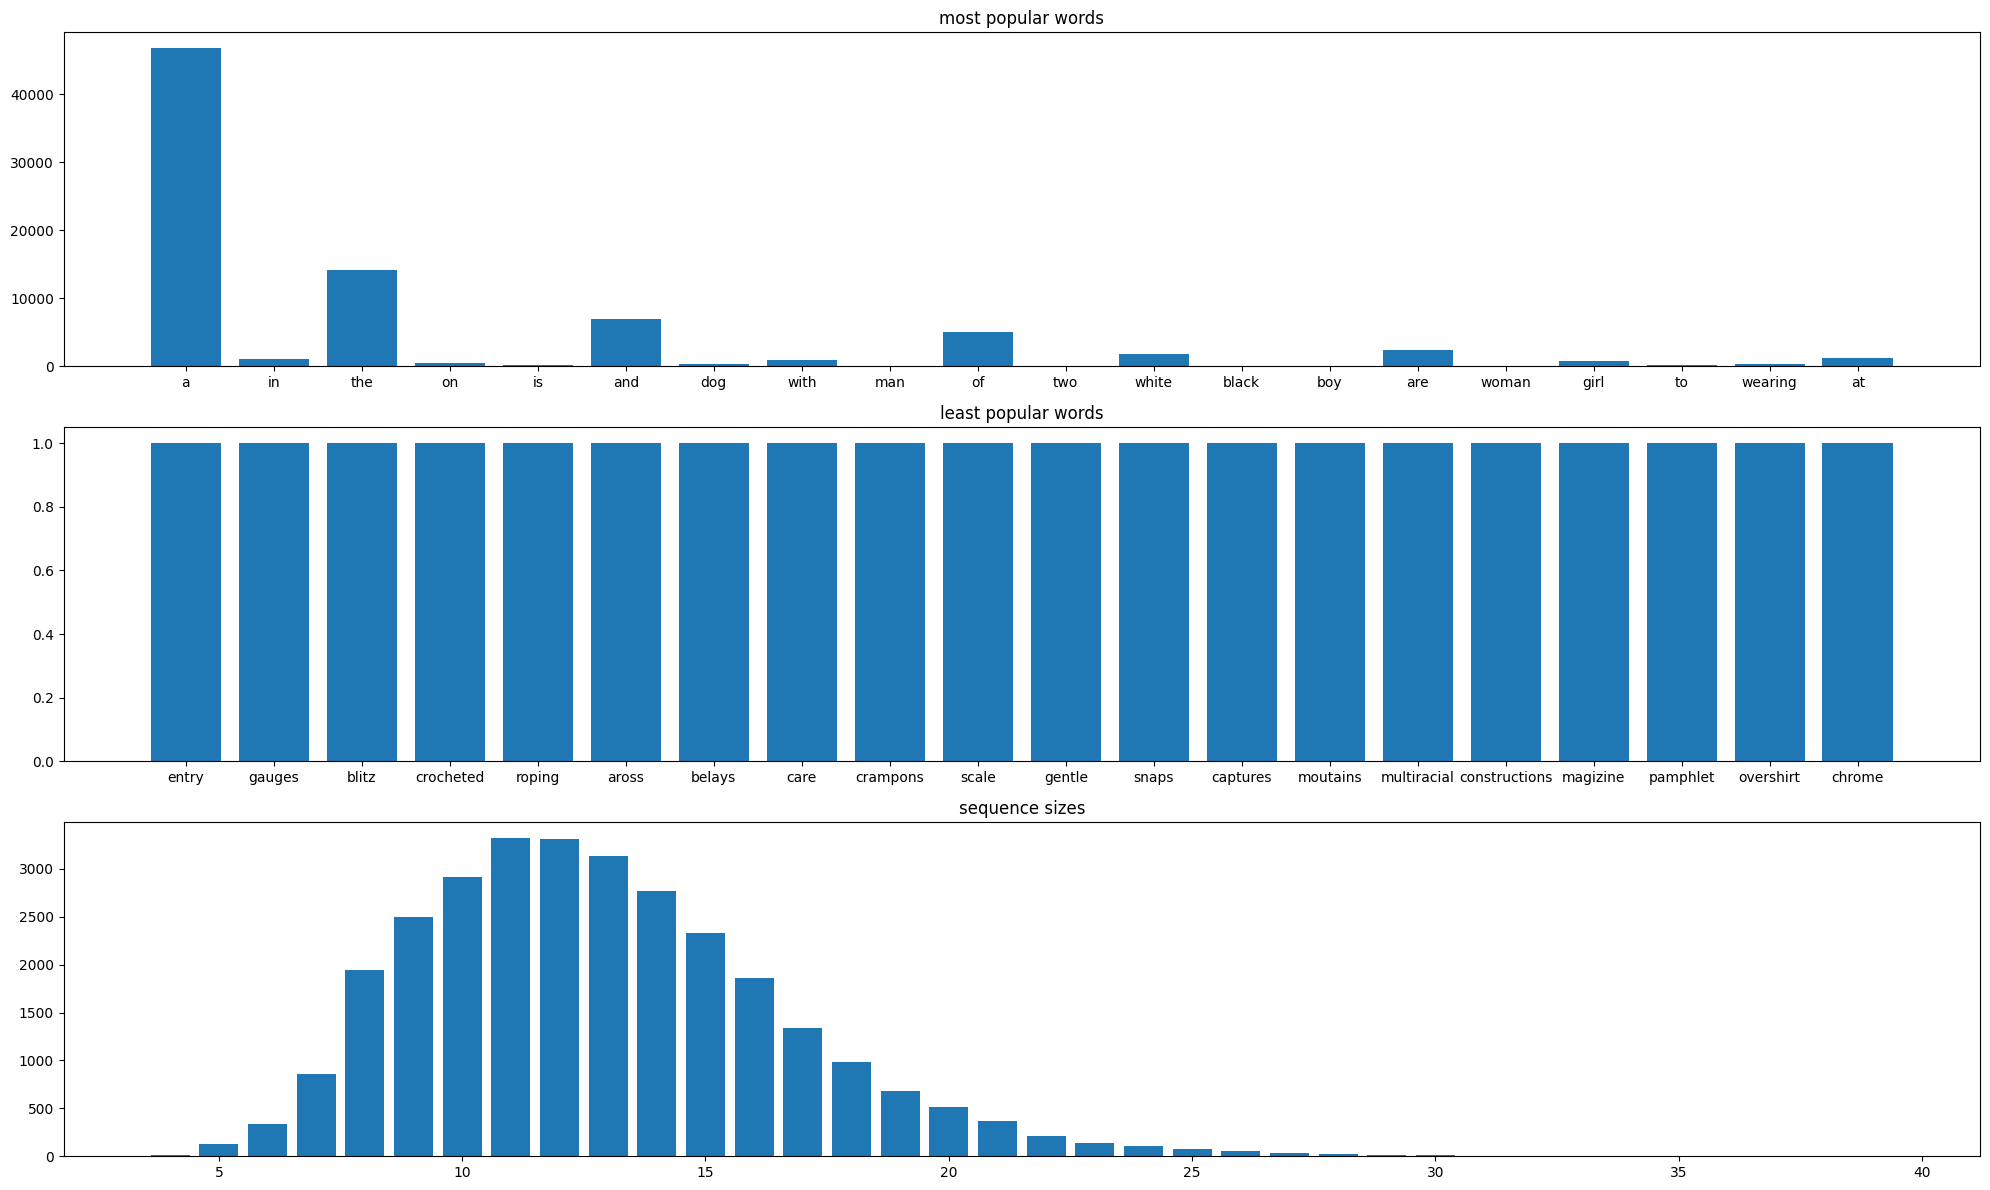

In [29]:
from tqdm.auto import trange
from collections import Counter

freq_diff_tokens = Counter()
sizes = Counter()

for i in trange(len(dfs['train'])):
  row = dfs['train'].iloc[i]
  for j in range(5):
    tokens = tokenize(row[f'caption #{j}'])
    sizes[len(tokens)] += 1
    freq_diff_tokens.update(tokens[1:-1])

print(freq_diff_tokens)
print(len(freq_diff_tokens))
print(sizes)


global_max_seq_len = np.max(list(sizes.keys()))

show_ = 20
fig, ax = plt.subplots(3, 1, figsize=(20, 12))

plt.subplot(312)
vocab_freq = {k: v for k, v in sorted(freq_diff_tokens.items(), key=lambda item: item[1])}
plt.title('least popular words')
plt.bar(list(vocab_freq.keys())[:show_], list(vocab_freq.values())[:show_])

plt.subplot(311)
vocab_freq = {k: v for k, v in sorted(freq_diff_tokens.items(), key=lambda item: item[1], reverse=True)}
plt.title('most popular words')
plt.bar(list(vocab_freq.keys())[:show_], list(freq_diff_tokens.values())[:show_])

plt.subplot(313)
plt.title('sequence sizes')
plt.bar(list(sizes.keys()), list(sizes.values()))

fig.tight_layout()
plt.show()

In [ ]:
MIN_FREQ = 3

token_to_index = {
    '<BOS>': 0,
    '<EOS>': 1,
    '<UNK>': 2,
    '<PAD>': 3
}

index_to_token = {
    0: '<BOS>',
    1: '<EOS>',
    3: '<UNK>',
    4: '<PAD>'
}